# Retail Sales Data Analysis

This project analyses retail sales data from four grocery stores to identify sales patterns, revenue performance, and useful business insights.

The first step is to load and inspect the dataset before making any changes to the data.

In [24]:
import pandas as pd

df = pd.read_csv("data/sales_data.csv")

df.head()

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
0,2026-01-31,T1000,P006,Full Cream Milk 2L,Dairy,Sandton,9.0,34.0,Cash
1,2026-06-03,T1001,P010,Beef Mince 1kg,Meat,Pretoria,9.0,135.0,Mobile
2,2026-05-31,T1002,P008,Tomatoes 1kg,Produce,Sandton,4.0,30.0,Card
3,2026-01-29,T1003,P005,Cheddar Cheese 500g,Dairy,Sandton,14.0,95.0,Mobile
4,2026-01-03,T1004,P008,Tomatoes 1kg,Produce,Soweto,11.0,30.0,Cash


## Inspecting the Dataset

Before cleaning the data, we will inspect the columns, data types, and number of records.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            600 non-null    object 
 1   transaction_id  600 non-null    object 
 2   product_id      600 non-null    object 
 3   product_name    600 non-null    object 
 4   category        600 non-null    object 
 5   store           600 non-null    object 
 6   quantity        599 non-null    float64
 7   unit_price      600 non-null    object 
 8   payment_method  600 non-null    object 
dtypes: float64(1), object(8)
memory usage: 42.3+ KB


## Checking Data Quality

We will check the dataset for missing values, invalid values, duplicates, and inconsistent text before cleaning it.

In [26]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique payment methods:")
print(df["payment_method"].unique())

print("\nUnique stores:")
print(df["store"].unique())

print("\nUnique categories:")
print(df["category"].unique())

Missing values:
date              0
transaction_id    0
product_id        0
product_name      0
category          0
store             0
quantity          1
unit_price        0
payment_method    0
dtype: int64

Duplicate rows:
1

Unique payment methods:
['Cash' 'Mobile' 'Card' 'EFT']

Unique stores:
['Sandton' 'Pretoria' 'Soweto' 'Rosebank' '  soweto ']

Unique categories:
['Dairy' 'Meat' 'Produce' 'Beverages' 'Bakery' 'beverages']


In [27]:
print("Unique quantity values that are negative:")
print(df[df["quantity"] < 0]["quantity"])

print("\nNon-numeric unit prices:")
print(df[~df["unit_price"].astype(str).str.replace(".", "", regex=False).str.isnumeric()]["unit_price"])

print("\nDates with different formatting:")
print(df[df["date"].str.contains("/", na=False)]["date"])

Unique quantity values that are negative:
200   -3.0
Name: quantity, dtype: float64

Non-numeric unit prices:
42    unknown
Name: unit_price, dtype: object

Dates with different formatting:
120    03/15/2026
Name: date, dtype: object


## Cleaning the Dataset

The dataset contains missing, invalid, duplicate, and inconsistent values. We will clean these issues before carrying out the sales analysis.

In [28]:
import pandas as pd

df = pd.read_csv("data/sales_data.csv")

print("Original rows:", len(df))

Original rows: 600


In [29]:
# Record the starting number of rows
starting_rows = len(df)

# Remove duplicate rows
df = df.drop_duplicates()

# Convert unit_price to numeric
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# Remove rows with missing quantity or unit_price
df = df.dropna(subset=["quantity", "unit_price"])

# Remove rows with negative quantity
df = df[df["quantity"] >= 0]

# Clean text values
df["store"] = df["store"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

# Convert dates with different formats into a consistent date format
df["date"] = pd.to_datetime(df["date"], format="mixed")

# Calculate how many rows were removed
removed_rows = starting_rows - len(df)

print("DATA-QUALITY REPORT")
print("-------------------")
print("Starting rows:", starting_rows)
print("Rows removed:", removed_rows)
print("Clean rows remaining:", len(df))

DATA-QUALITY REPORT
-------------------
Starting rows: 600
Rows removed: 4
Clean rows remaining: 596


In [30]:
print("\nRows removed by issue:")
print("Duplicate rows: 1")
print("Missing quantity: 1")
print("Invalid unit price: 1")
print("Negative quantity: 1")


Rows removed by issue:
Duplicate rows: 1
Missing quantity: 1
Invalid unit price: 1
Negative quantity: 1


In [31]:
print("Remaining missing values:")
print(df.isnull().sum())

print("\nRemaining duplicate rows:")
print(df.duplicated().sum())

print("\nUnique stores:")
print(df["store"].unique())

print("\nUnique categories:")
print(df["category"].unique())

print("\nNegative quantities remaining:")
print((df["quantity"] < 0).sum())

Remaining missing values:
date              0
transaction_id    0
product_id        0
product_name      0
category          0
store             0
quantity          0
unit_price        0
payment_method    0
dtype: int64

Remaining duplicate rows:
0

Unique stores:
['Sandton' 'Pretoria' 'Soweto' 'Rosebank']

Unique categories:
['Dairy' 'Meat' 'Produce' 'Beverages' 'Bakery']

Negative quantities remaining:
0


## Revenue and Key Performance Indicators

We will calculate revenue for each transaction and then determine the overall sales performance of the dataset.

In [32]:
df["revenue"] = df["quantity"] * df["unit_price"]

total_revenue = df["revenue"].sum()
total_quantity = df["quantity"].sum()
average_transaction_value = df["revenue"].mean()

print("Total revenue:", total_revenue)
print("Total quantity sold:", total_quantity)
print("Average transaction value:", average_transaction_value)

Total revenue: 324303.0
Total quantity sold: 4629.0
Average transaction value: 544.1325503355705


## Revenue by Category

We will compare total revenue across the different product categories.

In [33]:
revenue_by_category = df.groupby("category")["revenue"].sum()

print(revenue_by_category)

category
Bakery        22518.0
Beverages    109320.0
Dairy         65604.0
Meat         104055.0
Produce       22806.0
Name: revenue, dtype: float64


## Revenue by Store

We will compare total revenue across the four stores.

In [34]:
revenue_by_store = df.groupby("store")["revenue"].sum()

print(revenue_by_store)

store
Pretoria    84412.0
Rosebank    67184.5
Sandton     89137.5
Soweto      83569.0
Name: revenue, dtype: float64


## Monthly Revenue Trend

We will examine how revenue changes across the months in the dataset.

In [35]:
monthly_revenue = df.groupby(df["date"].dt.to_period("M"))["revenue"].sum()

print(monthly_revenue)

date
2026-01    44140.0
2026-02    47411.5
2026-03    37588.0
2026-04    57409.0
2026-05    77000.0
2026-06    58026.5
2026-07     2728.0
Freq: M, Name: revenue, dtype: float64


## Top 5 Products by Revenue

We will identify the five products that generated the highest total revenue.

In [36]:
top_products = df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(5)

print(top_products)

product_name
Coffee Beans 1kg       77760.0
Chicken Breasts 1kg    53160.0
Beef Mince 1kg         50895.0
Cheddar Cheese 500g    46360.0
Rooibos Tea 100g       31350.0
Name: revenue, dtype: float64


## Revenue by Category

This chart compares total revenue across the different product categories.

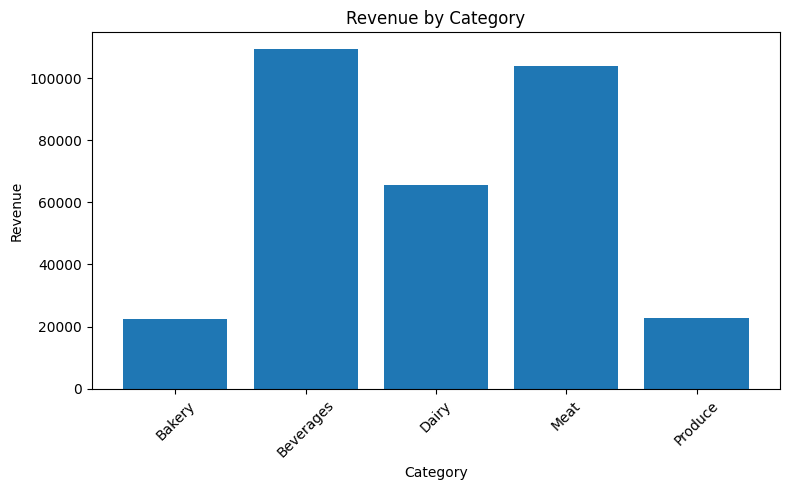

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(revenue_by_category.index, revenue_by_category.values)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/revenue_by_category.png")
plt.show()

## Revenue by Store

This chart compares total revenue across the four stores.

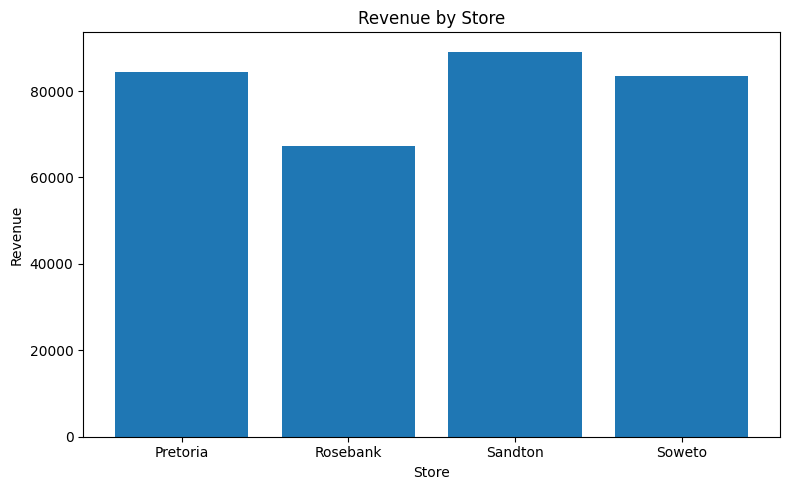

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(revenue_by_store.index, revenue_by_store.values)

plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("charts/revenue_by_store.png")
plt.show()

## Monthly Revenue Trend

This chart shows how total revenue changed from month to month.

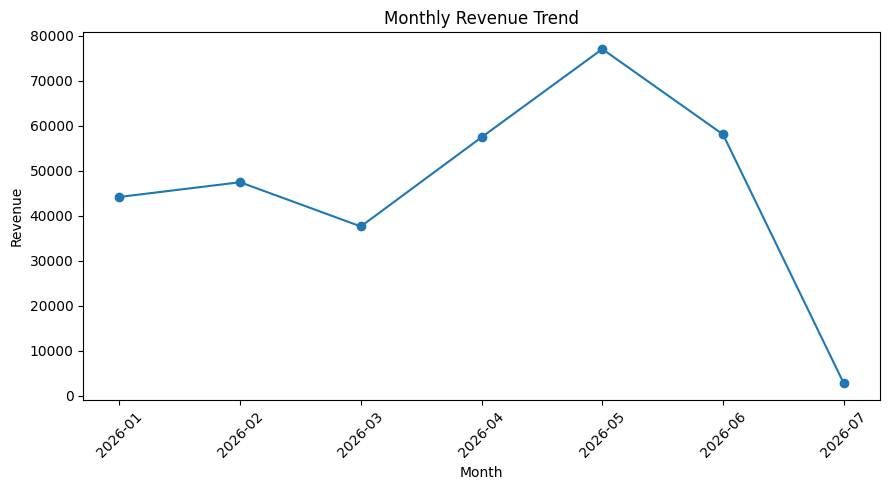

In [39]:
plt.figure(figsize=(9, 5))

plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/monthly_revenue_trend.png")
plt.show()

## Business Insights and Recommendations

### Key Findings

- Revenue varies across product categories, with Beverages and Meat generating the largest category revenues.
- Revenue also varies across stores, with Sandton generating the highest revenue and Rosebank the lowest.
- Monthly revenue changes over the period, with May recording the highest monthly revenue.
- Coffee Beans 1kg generated the highest revenue among the products analysed.
- July has substantially lower revenue than the preceding months, so the shorter period represented in the dataset should be considered before drawing conclusions.

### Recommendations

- Review the performance of the higher-revenue categories to understand which products are driving their results.
- Investigate the lower revenue at Rosebank to identify possible opportunities for improvement.
- Monitor monthly sales patterns and investigate significant changes in revenue.
- Review the performance and availability of high-revenue products such as Coffee Beans 1kg.